# Customer Churn Prediction using Machine Learning

## Business Problem

Customer churn is one of the most important business challenges for subscription-based companies. Retaining existing customers is generally more cost-effective than acquiring new ones. The goal of this project is to develop a machine learning model that predicts whether a customer is likely to leave the company, allowing businesses to proactively target retention efforts.

## Project Objectives

- Explore and understand the customer data
- Clean and prepare the dataset
- Perform exploratory data analysis (EDA)
- Engineer features for machine learning
- Train multiple classification models
- Evaluate model performance
- Identify the most important factors influencing customer churn
- Provide business recommendations based on the results

## Import Libraries

In [295]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

import warnings
warnings.filterwarnings("ignore")

## Import Dataset

In [296]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


## Load Dataset

In [297]:
df = pd.read_csv(
    "/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Data Overview

Before building any machine learning model, it is important to understand the structure and quality of the dataset. This section examines the dimensions, data types, summary statistics, and missing values.

In [298]:
df.shape

(7043, 21)

### Dataset Dimensions

In [299]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 7043
Columns: 21


### First Five Records

In [300]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Data Types

In [301]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### Summary Statistics

In [302]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### Missing Values

In [303]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Data Cleaning

This section prepares the dataset for machine learning by correcting data types, handling blank values, removing irrelevant identifiers, and checking for duplicate records.

In [304]:
# Check for duplicate records
df.duplicated().sum()

np.int64(0)

### Convert TotalCharges to Numeric

The `TotalCharges` column is stored as an object even though it represents a numeric value. This usually means the column contains blank or non-numeric values that need to be corrected.

In [305]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df["TotalCharges"].isnull().sum()

np.int64(11)

### Handle Missing Values

After converting `TotalCharges` to a numeric data type, 11 records contained missing values. Since these represent a very small percentage of the dataset, the missing records are removed to avoid introducing bias through imputation.

In [306]:
# Remove rows with missing TotalCharges
df.dropna(inplace=True)

# Verify missing values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### Remove Customer Identifier

The `customerID` column is a unique identifier and does not provide predictive value for machine learning. It is removed before model development.

In [307]:
# Remove customer identifier
df.drop("customerID", axis=1, inplace=True)

# Verify the remaining columns
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps identify patterns, relationships, and trends within the dataset. Understanding these characteristics provides valuable insights into customer behavior and supports better feature selection for machine learning models.

### Target Variable Distribution

In [308]:
# Display churn counts
df["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

### Visualize Customer Churn

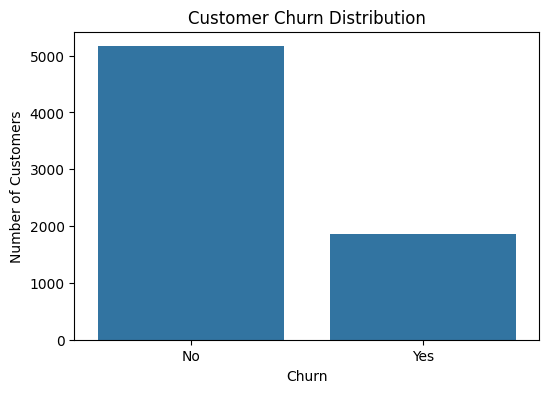

In [309]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

### Churn Percentage

In [310]:
churn_percentage = df["Churn"].value_counts(normalize=True) * 100

print(churn_percentage)

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


### Churn by Contract Type

Customer contract type is often one of the strongest indicators of customer retention. This analysis examines whether contract length influences customer churn.

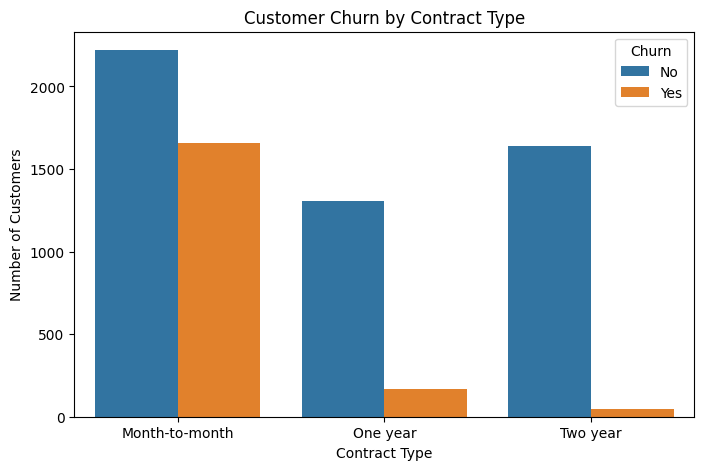

In [311]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

### Churn by Internet Service

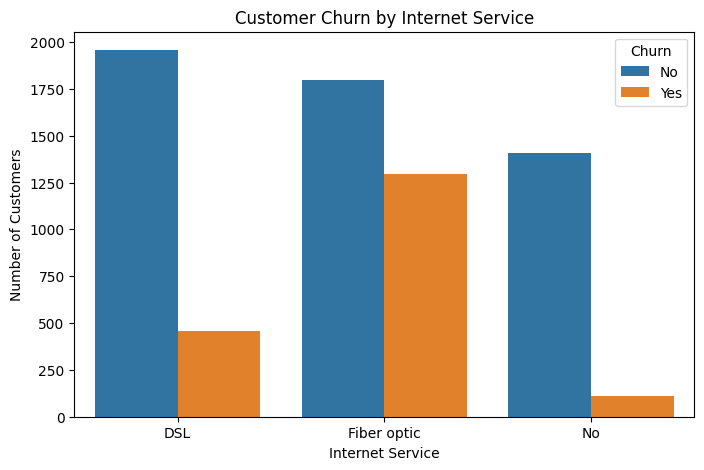

In [312]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn"
)

plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

### Monthly Charges Distribution

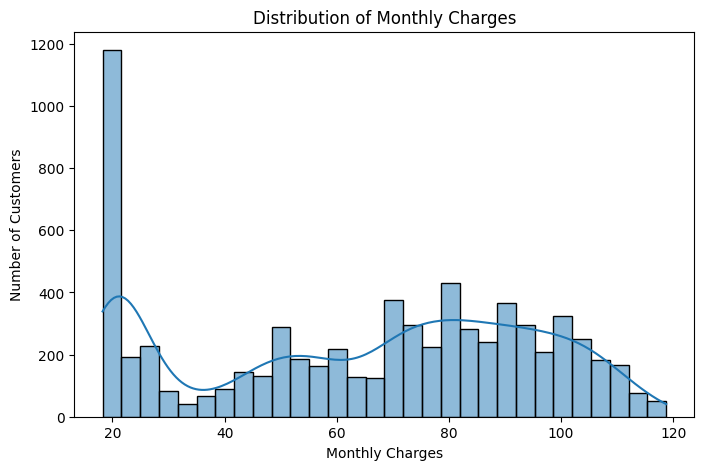

In [313]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="MonthlyCharges",
    bins=30,
    kde=True
)

plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

plt.show()

### Correlation Between Numerical Features

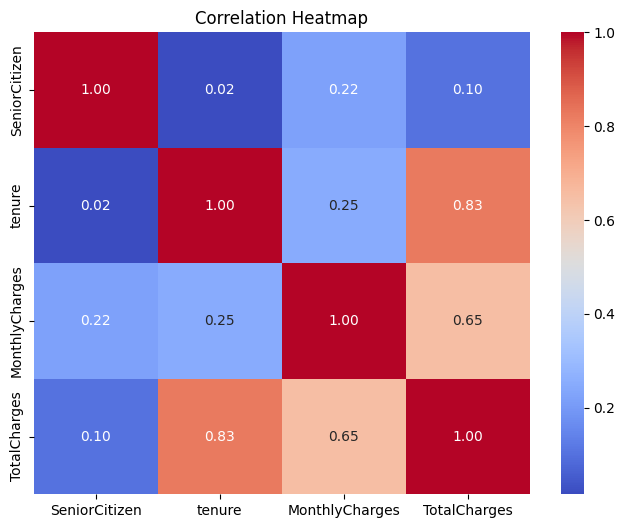

In [314]:
# Select numerical features
numerical_features = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(8,6))

sns.heatmap(
    numerical_features.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

### Customer Tenure by Churn Status

Customer tenure measures how long a customer has remained with the company. This visualization helps determine whether long-term customers are less likely to leave.

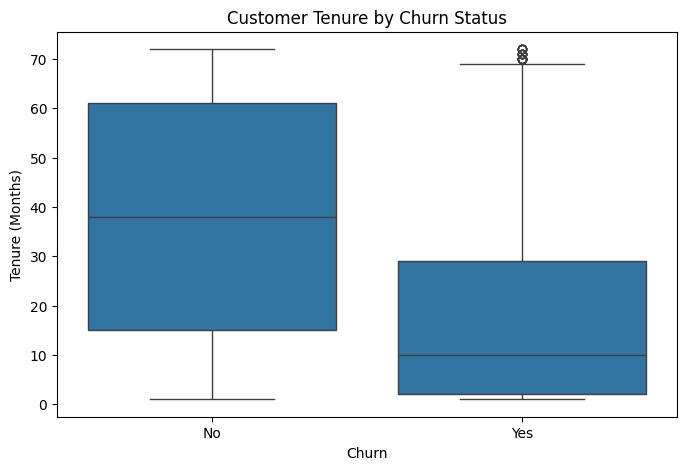

In [315]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Customer Tenure by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

### Monthly Charges by Churn Status

This visualization compares monthly charges for customers who stayed versus those who left the company.

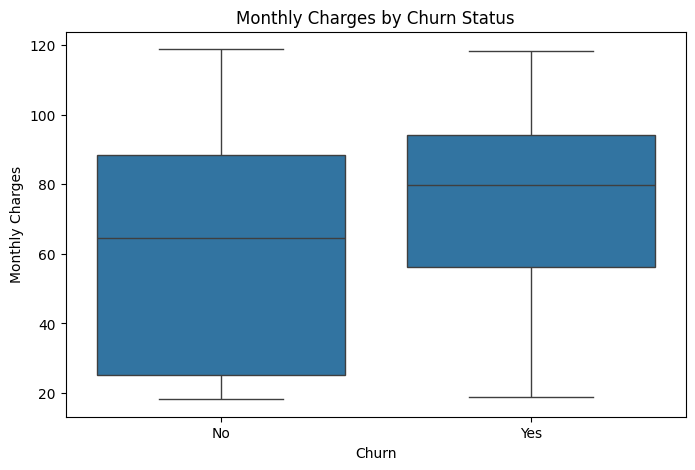

In [316]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

# Feature Engineering

Machine learning models require numerical input. This section converts categorical variables into numerical values, prepares the target variable, and creates the training and testing datasets.

## Encode the Target Variable

The target variable (`Churn`) is converted from text labels (`Yes` and `No`) into binary values where:

- Yes = 1
- No = 0

In [317]:
# Encode target variable
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

df["Churn"].head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

## Encode Categorical Features

Machine learning algorithms cannot directly process text values. All remaining categorical features are converted into numerical representations using one-hot encoding.

In [318]:
# One-hot encode categorical variables
df_encoded = pd.get_dummies(df, drop_first=True)

df_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


## Separate Features and Target

The dataset is divided into:

- Features (`X`)
- Target (`y`)

In [319]:
X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

print(X.shape)
print(y.shape)

(7032, 30)
(7032,)


## Split Training and Testing Data

The dataset is divided into training and testing sets.

- 80% Training
- 20% Testing

The `random_state` parameter ensures reproducible results.

In [320]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set :", X_test.shape)

Training Set: (5625, 30)
Testing Set : (1407, 30)


# Model Training

This section trains multiple classification models and compares their ability to predict customer churn.

## Logistic Regression Baseline Model

Logistic Regression is used as the baseline model because it is simple, interpretable, and commonly used for binary classification problems.

In [321]:
# Train Logistic Regression model
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

# Make predictions
log_predictions = log_model.predict(X_test)
log_probabilities = log_model.predict_proba(X_test)[:, 1]

## Logistic Regression Evaluation

In [322]:
print("Accuracy:", accuracy_score(y_test, log_predictions))
print("ROC-AUC:", roc_auc_score(y_test, log_probabilities))
print("\nClassification Report:")
print(classification_report(y_test, log_predictions))

Accuracy: 0.8031272210376688
ROC-AUC: 0.8363897790040947

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



## Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve predictive performance and reduce overfitting.

In [323]:
# Train Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

# Predictions
rf_predictions = rf_model.predict(X_test)
rf_probabilities = rf_model.predict_proba(X_test)[:, 1]

## Random Forest Evaluation

In [324]:
print("Accuracy:", accuracy_score(y_test, rf_predictions))
print("ROC-AUC:", roc_auc_score(y_test, rf_probabilities))
print("\nClassification Report:")
print(classification_report(y_test, rf_predictions))

Accuracy: 0.7896233120113717
ROC-AUC: 0.8164903116927489

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.63      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



## Confusion Matrix

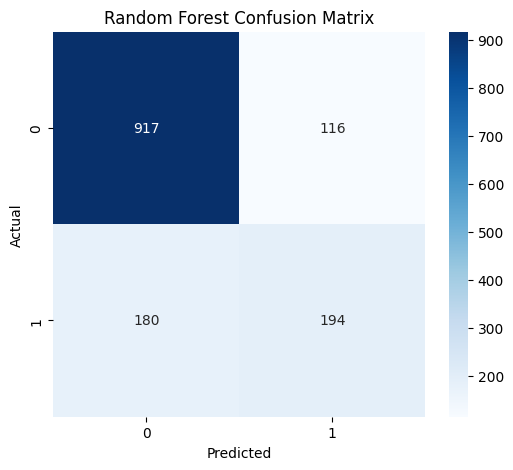

In [325]:
plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(y_test, rf_predictions),
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## XGBoost Classifier

XGBoost is a gradient boosting algorithm that often performs well on structured tabular datasets.

In [326]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

xgb_predictions = xgb_model.predict(X_test)
xgb_probabilities = xgb_model.predict_proba(X_test)[:, 1]

## XGBoost Evaluation

In [327]:
print("Accuracy:", accuracy_score(y_test, xgb_predictions))
print("ROC-AUC:", roc_auc_score(y_test, xgb_probabilities))
print("\nClassification Report:")
print(classification_report(y_test, xgb_predictions))

Accuracy: 0.8052594171997157
ROC-AUC: 0.8414500623799638

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1033
           1       0.67      0.53      0.59       374

    accuracy                           0.81      1407
   macro avg       0.76      0.72      0.73      1407
weighted avg       0.80      0.81      0.80      1407



# Model Comparison

The performance of all three classification models is summarized below.

In [328]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, log_predictions),
        accuracy_score(y_test, rf_predictions),
        accuracy_score(y_test, xgb_predictions)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, log_probabilities),
        roc_auc_score(y_test, rf_probabilities),
        roc_auc_score(y_test, xgb_probabilities)
    ]
})

comparison.sort_values("ROC-AUC", ascending=False)

,Model,Accuracy,ROC-AUC
2,XGBoost,0.805259,0.84145
0,Logistic Regression,0.803127,0.83639
1,Random Forest,0.789623,0.81649


# Feature Importance

Understanding which variables contribute most to customer churn provides valuable business insight beyond predictive accuracy.

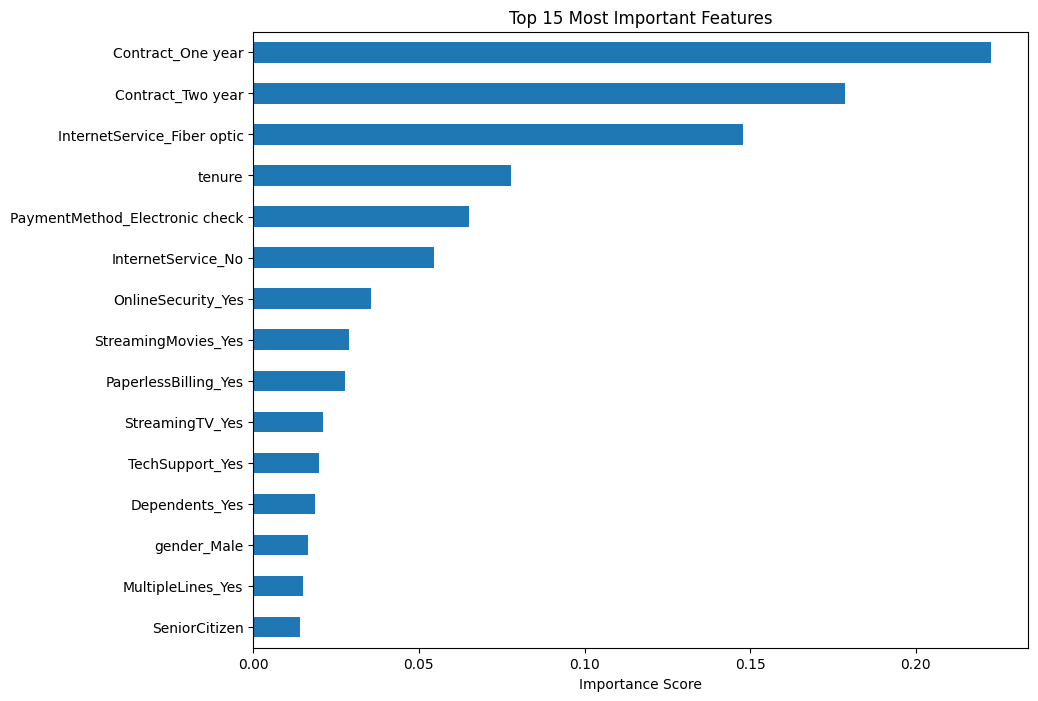

In [329]:
feature_importance = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,8))

feature_importance.head(15).plot(kind="barh")

plt.title("Top 15 Most Important Features")
plt.xlabel("Importance Score")

plt.gca().invert_yaxis()

plt.show()

# Business Recommendations

Based on the model results, several factors appear to influence customer churn.

Key observations include:

- Month-to-month contracts are associated with higher churn.
- Customers with shorter tenure are more likely to leave.
- Higher monthly charges are associated with increased churn.
- Contract length is one of the strongest predictors of retention.

Organizations can use these insights to identify at-risk customers and proactively target retention programs before customers leave.

# Conclusion

This project developed and compared three machine learning classification models to predict customer churn.

Among the evaluated models, XGBoost achieved the strongest overall performance with the highest ROC-AUC score, making it the preferred model for this dataset.

The project demonstrates a complete end-to-end machine learning workflow including:

- Data cleaning
- Exploratory Data Analysis
- Feature engineering
- Classification modeling
- Model comparison
- Business interpretation

These techniques can be applied to customer retention initiatives across telecommunications, finance, healthcare, software-as-a-service, and other subscription-based industries.

# Portfolio Discussion

## What business problem does this solve?

Customer churn directly impacts revenue and customer lifetime value. By identifying customers who are likely to leave, organizations can proactively target retention efforts, reduce revenue loss, and improve long-term profitability.

---

## Why was XGBoost selected?

Three machine learning models were evaluated:

- Logistic Regression
- Random Forest
- XGBoost

XGBoost achieved the highest ROC-AUC score (0.841), indicating the strongest ability to distinguish between customers who churn and those who remain. It also maintained competitive accuracy while capturing more complex relationships within the data.

---

## How would this model be deployed?

In a production environment, the trained model could be deployed as a REST API using FastAPI. Customer records from a CRM system would be submitted to the API, which would return a churn probability. High-risk customers could then be automatically routed into retention campaigns, customer success workflows, or sales outreach.

---

## Future Improvements

Potential enhancements include:

- Hyperparameter optimization using GridSearchCV or Optuna
- Cross-validation for more robust model evaluation
- SHAP explainability for feature-level interpretation
- Threshold optimization to improve recall for high-risk customers
- Deployment using Docker and FastAPI

# Lessons Learned

This project reinforced several important machine learning concepts:

- Data preprocessing has a significant impact on model performance.
- Converting categorical variables into numerical features is essential for classification algorithms.
- ROC-AUC provides a more informative evaluation metric than accuracy alone for moderately imbalanced datasets.
- XGBoost outperformed both Logistic Regression and Random Forest on this customer churn dataset.
- Machine learning projects should focus on business value in addition to predictive performance.